In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv(r"C:\Users\anjal\PyTorch\ANN\data\fmnist_small.csv")

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


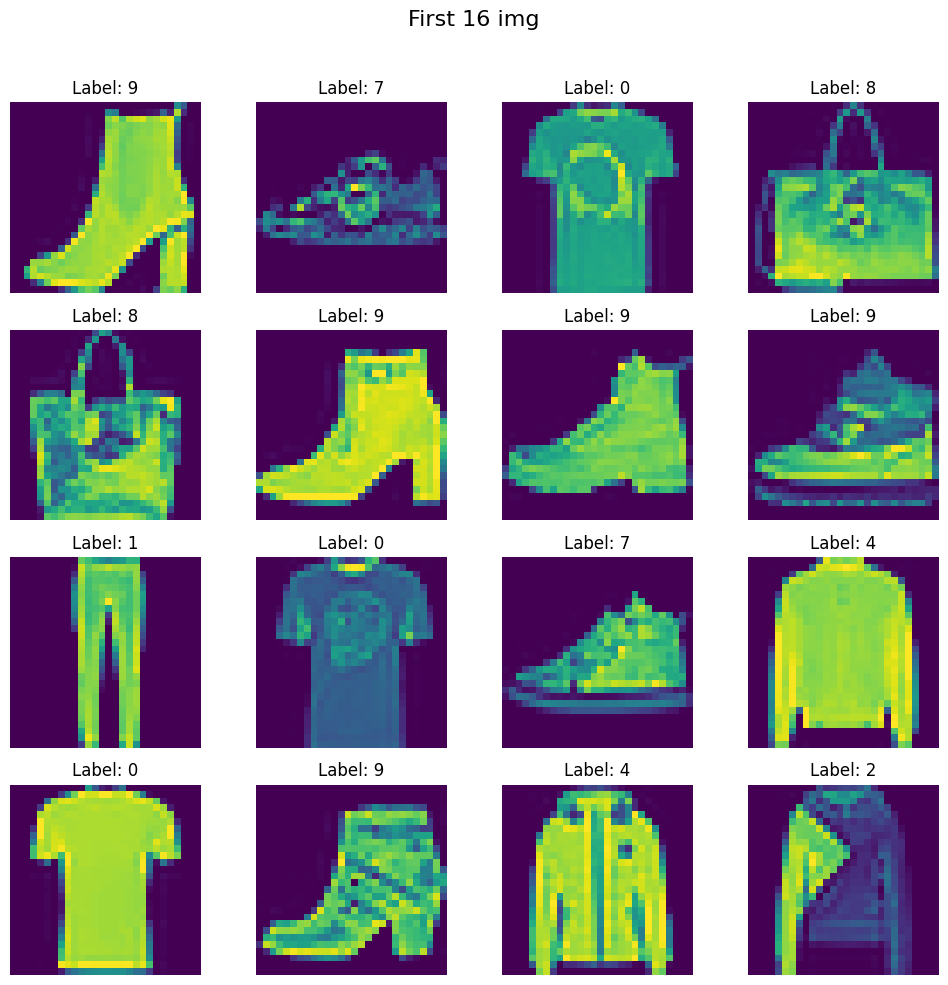

In [5]:
fig ,axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 img",fontsize = 16)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout(rect = [0,0,1,0.96])
plt.show()

In [6]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
X_train ,X_test , y_train ,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
X_train = X_train/255.0
X_test = X_test/255.0

In [15]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = torch.tensor(features.to_numpy(),dtype=torch.float32)
        self.labels = torch.tensor(labels.to_numpy(),dtype=torch.long)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index],self.labels[index]

In [16]:
train_dataset = CustomDataset(X_train,y_train)

In [18]:
test_dataset = CustomDataset(X_test,y_test)

In [19]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [20]:
class MyNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)
    
    

In [21]:
learning_rate = 0.1
epochs =100

In [23]:
model = MyNN(X_train.shape[1])

loss_fun = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [24]:
for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features,batch_labels in train_loader:
        
        y_pred = model(batch_features)

        loss = loss_fun(y_pred,batch_labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

Epoch: 1, Loss: 1.3513192017873128
Epoch: 2, Loss: 0.8018482400973638
Epoch: 3, Loss: 0.6689845565954844
Epoch: 4, Loss: 0.5903442335128785
Epoch: 5, Loss: 0.5410629083712896
Epoch: 6, Loss: 0.5036374664306641
Epoch: 7, Loss: 0.4758427349726359
Epoch: 8, Loss: 0.464943114121755
Epoch: 9, Loss: 0.43504883999625843
Epoch: 10, Loss: 0.4131951313714186
Epoch: 11, Loss: 0.38914394358793897
Epoch: 12, Loss: 0.3702426117658615
Epoch: 13, Loss: 0.3605150722960631
Epoch: 14, Loss: 0.3448305150369803
Epoch: 15, Loss: 0.33882034704089165
Epoch: 16, Loss: 0.31122887154420215
Epoch: 17, Loss: 0.306065534055233
Epoch: 18, Loss: 0.29684911934038005
Epoch: 19, Loss: 0.2824729591608047
Epoch: 20, Loss: 0.2738199589153131
Epoch: 21, Loss: 0.2649429583052794
Epoch: 22, Loss: 0.25580664147933324
Epoch: 23, Loss: 0.24214101001620292
Epoch: 24, Loss: 0.2536137080937624
Epoch: 25, Loss: 0.2417056697855393
Epoch: 26, Loss: 0.22115066389242807
Epoch: 27, Loss: 0.22126937665045263
Epoch: 28, Loss: 0.20526889103

In [25]:
model.eval()


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [26]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features,batch_labels in test_loader:

        y_pred = model(batch_features)

        #extract labels
        _, predicted = torch.max(y_pred,1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)




0.8391666666666666
